In [ ]:
# Basic operating system (os), numerical, and plotting functionality
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import random
import gc
#import cv2

# scipy statistics functions
from scipy.stats import mode, moment

# scikit-learn data utilities and metrics
from sklearn.datasets import make_blobs
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, completeness_score
from sklearn.preprocessing import LabelEncoder

# Color transformations
from skimage.color import rgb2lab

# Feature extractors and clustering
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
from sklearn.cluster import KMeans

# TensorFlow and Keras utilities
import tensorflow as tf
from tensorflow.keras.applications import VGG16, EfficientNetB5
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.applications.imagenet_utils import decode_predictions
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers

# Set plotting preferences
import matplotlib
%matplotlib inline
font = {'family': 'sans-serif', 'weight': 'normal', 'size': 16}
matplotlib.rc('font', **font)

2024-08-02 13:46:08.484473: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-08-02 13:46:09.550342: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/nvidia/lib:/usr/local/nvidia/lib64
2024-08-02 13:46:09.550457: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer_plugin.so.7'; dlerror: libnvinfer_plugin.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/nvidia/lib:/usr/local/nvidia/lib64
2024-08-02 13:46:09.550466: W tensorfl

In [ ]:
# Attempt to load the DataFrame again with the correct path
file_path = '/work/full_df.csv'
df = pd.read_csv(file_path)
df.head(50)

,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,Left-Diagnostic Keywords,Right-Diagnostic Keywords,N,D,G,C,A,H,M,O,filepath,labels,target,filename
0,0,69,Female,0_left.jpg,0_right.jpg,cataract,normal fundus,0,0,0,1,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",0_right.jpg
1,1,57,Male,1_left.jpg,1_right.jpg,normal fundus,normal fundus,1,0,0,0,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",1_right.jpg
2,2,42,Male,2_left.jpg,2_right.jpg,laser spot，moderate non proliferative retinopathy,moderate non proliferative retinopathy,0,1,0,0,0,0,0,1,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",2_right.jpg
3,4,53,Male,4_left.jpg,4_right.jpg,macular epiretinal membrane,mild nonproliferative retinopathy,0,1,0,0,0,0,0,1,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",4_right.jpg
4,5,50,Female,5_left.jpg,5_right.jpg,moderate non proliferative retinopathy,moderate non proliferative retinopathy,0,1,0,0,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",5_right.jpg
5,6,60,Male,6_left.jpg,6_right.jpg,macular epiretinal membrane,moderate non proliferative retinopathy，epireti...,0,1,0,0,0,0,0,1,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",6_right.jpg
6,7,60,Female,7_left.jpg,7_right.jpg,drusen,mild nonproliferative retinopathy,0,1,0,0,0,0,0,1,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",7_right.jpg
7,8,59,Male,8_left.jpg,8_right.jpg,normal fundus,normal fundus,1,0,0,0,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",8_right.jpg
8,9,54,Male,9_left.jpg,9_right.jpg,normal fundus,vitreous degeneration,0,0,0,0,0,0,0,1,../input/ocular-disease-recognition-odir5k/ODI...,['O'],"[0, 0, 0, 0, 0, 0, 0, 1]",9_right.jpg
9,10,70,Male,10_left.jpg,10_right.jpg,epiretinal membrane,normal fundus,0,0,0,0,0,0,0,1,../input/ocular-disease-recognition-odir5k/ODI...,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",10_right.jpg


In [ ]:
# Set the path to the Week 3 challenge data on GitHub
image_dir = '/work/Ocular_Disease_Recognition/preprocessed_images/'
image_paths = np.load('/work/imagePaths.npy')
image_files = np.load('/work/imagesFiles.npy')
image_files_resized = np.load('/work/imageFiles_Resized.npy')
image_files_resized2 = np.load('/work/imageFiles_Resized2.npy')

KeyboardInterrupt: 

In [ ]:
df['labels'].value_counts()

labels
['N']    2873
['D']    1608
['O']     708
['C']     293
['G']     284
['A']     266
['M']     232
['H']     128
Name: count, dtype: int64

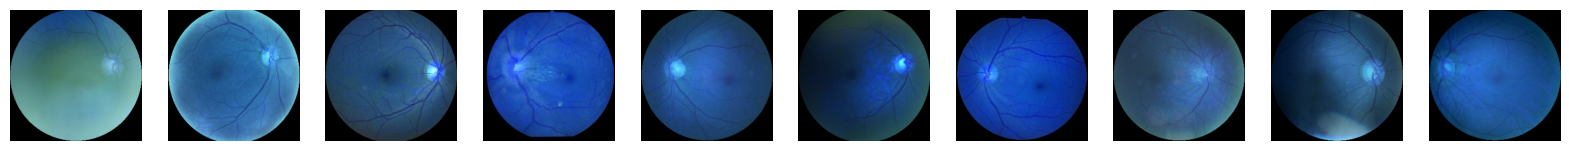

In [ ]:
num_images = 10
indices = np.random.choice(len(image_files_resized2), num_images, replace=False)
fig, axes = plt.subplots(1, num_images, figsize=(20, 2))
for idx, ax in enumerate(axes):
    ax.imshow(image_files_resized2[indices[idx]], cmap='gray')
    ax.axis('off') 
plt.show()

In [ ]:
df = df.sort_values(by='filename', ascending=True)

In [ ]:
labels_df = df['labels']

In [ ]:
labels_df.value_counts()

labels
['N']    2873
['D']    1608
['O']     708
['C']     293
['G']     284
['A']     266
['M']     232
['H']     128
Name: count, dtype: int64

In [ ]:
labels_df.head(10)

3194    ['C']
0       ['N']
858     ['N']
4065    ['N']
859     ['O']
4066    ['N']
860     ['O']
3279    ['O']
83      ['N']
4067    ['N']
Name: labels, dtype: object

In [ ]:
data = []
data_labels = []
index = 0
for label in labels_df:
    #if label != "['H']" and label != "['M']" and label != "['O']" and label != "['D']":
    if label != "['H']" and label != "['O']" and label != "['D']":
        data.append(image_files_resized2[index])  # Fix variable name here
        data_labels.append(label)
    index+=1  # Moved outside the if condition to traverse all labels

images_files_resized2 = data
labels_df = pd.DataFrame(data_labels)

# train test split

In [ ]:
stratify = labels_df

images_train, images_test, labels_train, labels_test = train_test_split(images_files_resized2, labels_df, test_size=0.15, random_state=42, shuffle = True, stratify=stratify)
images_train, images_val, labels_train, labels_val = train_test_split(images_train, labels_train, test_size=0.15, random_state=42, shuffle = True, stratify=labels_train)

In [ ]:
# Define some functions for experimenting with unfreezing layers
def unfreeze_layers(model, top_n_layers):
    """Makes the top layers of the `base_model` trainable (except batch norm)"""
    # We unfreeze the top layers while leaving BatchNorm layers frozen
    for layer in model.layers[-top_n_layers:]:
        if not isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = True

def freeze_layers(model, top_n_layers):
    """Makes the top layers of the `base_model` untrainable"""
    # We unfreeze the top layers while leaving BatchNorm layers frozen
    for layer in model.layers[-top_n_layers:]:
        if not isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False

# Data AUGMENTATION :3

In [ ]:
# # Modify the scalar function to add random noise
# def scalar(img):
#     noise_factor = 0.1  # Adjust the noise_factor to control the amount of noise
#     noise = np.random.randn(*img.shape) * noise_factor
#     img = img + noise
#     img = np.clip(img, 0., 1.)  # Ensure pixel values are within [0,1]
#     return img

# images_train = scalar(images_train)
    
# datagen = ImageDataGenerator(
#     #shear_range=0.1,             # Apply random shearing transformations up to 0.1 radians
#     # zoom_range=0.1,              # Zoom into images by up to 10%
#     horizontal_flip=True,  
#     vertical_flip = True,     # Avoid horizontal flips
#     #brightness_range=[0.8, 1.2], # Adjust brightness between 80% and 120%
#     #preprocessing_function=scalar
# )

# datagen.fit(images_train)

# Hot LABELING

In [ ]:
label_encoder = LabelEncoder()
labels_train_int = label_encoder.fit_transform(labels_train)
labels_val_int = label_encoder.transform(labels_val)
labels_test_int = label_encoder.transform(labels_test)

# Convert to categorical
num_classes = len(np.unique(labels_train_int))  # or a predefined number of classes
labels_train_categorical = tf.keras.utils.to_categorical(labels_train_int, num_classes)
labels_val_categorical = tf.keras.utils.to_categorical(labels_val_int, num_classes)
labels_test_categorical = tf.keras.utils.to_categorical(labels_test_int, num_classes)

images_train = np.array(images_train)
images_val = np.array(images_val)
images_test = np.array(images_test)

NameError: name 'labels_train' is not defined

Class=1, n=212 (7.436%)
Class=4, n=2075 (72.781%)
Class=0, n=192 (6.734%)
Class=3, n=167 (5.858%)
Class=2, n=205 (7.190%)


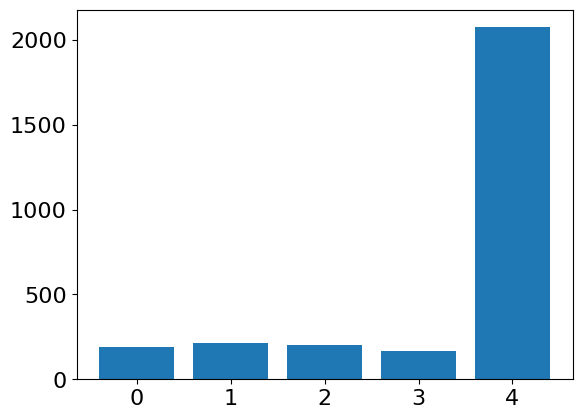

In [ ]:
from collections import Counter

counter = Counter(labels_train_int)
for k, v in counter.items():
    per = v / len(labels_train_int) * 100
    print('Class=%d, n=%d (%.3f%%)' % (k, v, per))

# plot the distribution
import matplotlib.pyplot as plt
plt.bar(counter.keys(), counter.values())
plt.show()

In [ ]:
# !pip install imblearn
# from imblearn.over_sampling import SMOTE
# import matplotlib.pyplot as plt  # Added import for pyplot
# from collections import Counter

# # Get the current distribution of classes in the training data
# counter = Counter(labels_train_int)
# print("Original Class Distribution:", counter)

# n_samples, height, width, channels = images_train.shape
# images_train_reshaped = images_train.reshape((n_samples, height * width * channels))

# smote = SMOTE()
# images_train_resampled, labels_train_resampled = smote.fit_resample(images_train_reshaped, labels_train_int)

# total_resampled = len(images_train_resampled)
# images_train_resampled = images_train_resampled.reshape((total_resampled, height, width, channels))

# counter = Counter(labels_train_resampled)
# for k, v in counter.items():
#     per = v / len(labels_train_resampled) * 100
#     print('Class=%d, n=%d (%.3f%%)' % (k, v, per))

# plt.bar(counter.keys(), counter.values())
# plt.show()

# labels_train = labels_train_resampled

NameError: name 'labels_train_int' is not defined

# FINAL Model (accuracy: 83%, F1: 0.6)

In [ ]:
from tensorflow.keras.applications import EfficientNetB5
from tensorflow.keras import metrics

base_resnet_model = EfficientNetB5(include_top=False, weights='imagenet', input_shape=(224, 224, 3), pooling=None)

layer_1 = tf.keras.layers.Conv2D(filters = 512, kernel_size = (3,3), padding='same', activation=tf.nn.relu)
layer_2 = tf.keras.layers.Conv2D(filters = 32, kernel_size = (3,3), padding='same', activation=tf.nn.relu)
max_pool = tf.keras.layers.MaxPooling2D(pool_size = (3,3), strides=2, padding='same')
max_pool2 = tf.keras.layers.MaxPooling2D(pool_size = (3,3), strides=2, padding='same')
dropout_layer = tf.keras.layers.Dropout(0.35)
dropout_layer2 = tf.keras.layers.Dropout(0.35)
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()
# Flatten the output before the dense layers
flatten_layer = tf.keras.layers.Flatten()
# Let's add a fully-connected layer
prediction_layer1 = tf.keras.layers.Dense(64, activation='relu')
# Add the final classification layer
prediction_layer2 = tf.keras.layers.Dense(5, activation='softmax', kernel_regularizer =tf.keras.regularizers.l1( l=0.01))
image_resnet_model = tf.keras.Sequential([
    base_resnet_model,
    BatchNormalization(),
    layer_1,
    max_pool,
    dropout_layer,
    # layer_2,
    # max_pool2,
    # dropout_layer2,
    global_average_layer,
    flatten_layer,
    #prediction_layer1,
    prediction_layer2
])

# Specify the loss function to use
loss_func = tf.keras.losses.categorical_crossentropy

# Use the RMSprop learning algorithm to optimize the network weights
base_learning_rate = 0.0001
opt = tf.keras.optimizers.Adam(learning_rate=base_learning_rate)

base_resnet_model.trainable = False
n_layers = 1
unfreeze_layers(image_resnet_model, n_layers)

# Compile the model using the specified loss function and potimizer
image_resnet_model.compile(loss=loss_func, optimizer=opt, metrics=['accuracy'])
#image_resnet_model.compile(loss=loss_func, optimizer=opt, metrics=[metrics.AUC(name='my_auc'), 'accuracy'])
image_resnet_model.summary()

2024-08-02 12:29:45.086921: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:975] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2024-08-02 12:29:45.101925: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:975] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2024-08-02 12:29:45.102986: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:975] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2024-08-02 12:29:45.105402: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags

In [ ]:
### Train Model

# This function is called after each epoch
# (It will ensure that your training process does not consume all available RAM)
class garbage_collect_callback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        gc.collect()

def configure_memory_growth():
    gpus = tf.config.experimental.list_physical_devices('GPU')
    if gpus:
        for gpu in gpus:
            try:
                tf.config.experimental.set_memory_growth(gpu, True)
                logical_gpus = tf.config.experimental.list_logical_devices('GPU')
                print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
            except RuntimeError as e:
                print(e)

# Configure GPU memory growth
configure_memory_growth()

labels_train = np.array(labels_train)
labels_val = np.array(labels_val)

early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

history = image_resnet_model.fit(images_train, # Train examples
                    labels_train_categorical, # Train labels
                    epochs=20, # number of epochs (passes through data during training)
                    batch_size=16,
                    callbacks=[garbage_collect_callback(), early_stopping],
                    validation_data= (images_val, labels_val_categorical), #val_dataset, # data to use for validation
                    verbose=1)
                    #class_weight=class_weight) # will print information about optimization process


Physical devices cannot be modified after being initialized
Epoch 1/20
2024-08-02 12:30:34.881607: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8204
179/179 [==============================] - 83s 359ms/step - loss: 2.2880 - accuracy: 0.7678 - val_loss: 2.0175 - val_accuracy: 0.8155
Epoch 2/20
179/179 [==============================] - 57s 321ms/step - loss: 1.9447 - accuracy: 0.8201 - val_loss: 1.8767 - val_accuracy: 0.7937
Epoch 3/20
179/179 [==============================] - 57s 321ms/step - loss: 1.8264 - accuracy: 0.8365 - val_loss: 1.8992 - val_accuracy: 0.8095
Epoch 4/20
179/179 [==============================] - 58s 323ms/step - loss: 1.6543 - accuracy: 0.8583 - val_loss: 1.8572 - val_accuracy: 0.8194
Epoch 5/20
179/179 [==============================] - 58s 323ms/step - loss: 1.5532 - accuracy: 0.8779 - val_loss: 1.9516 - val_accuracy: 0.8333
Epoch 6/20
179/179 [==============================] - 57s 321ms/step - loss: 1.4561 - accuracy: 0.8790 - val_l

In [ ]:
# Fixing the error by providing an existing directory path and saving the model there
save_model_path = 'model5Class.h5'
image_resnet_model.save(save_model_path)
print(f'Model saved to {save_model_path}')

Model saved to model5Class.h5


# confusion matrix >O<

19/19 [==============================] - 15s 495ms/step


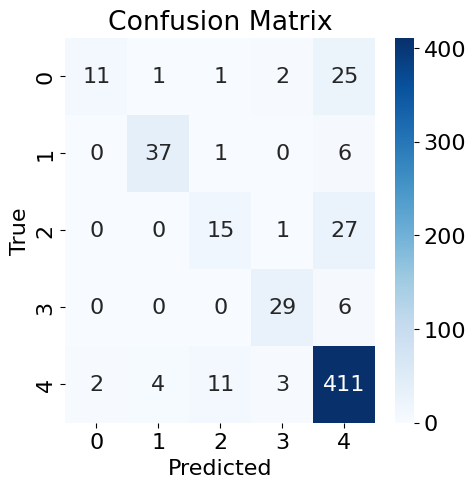

In [ ]:
# Import the required module for confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Make predictions on the test set
labels_test_pred = np.argmax(image_resnet_model.predict(images_test), axis=1)
labels_test_true = np.argmax(labels_test_categorical, axis=1)

# Compute the confusion matrix
cm = confusion_matrix(labels_test_true, labels_test_pred)

# Plot the confusion matrix
plt.figure(figsize=(5, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# TEST RESULTS - RUN AT END

test_pred = image_resnet_model.evaluate(images_test, labels_test_categorical, verbose=1)
print('\nTesting model on validation set:')
print(f'Model Loss: {test_pred[0]:.3f}, Model Accuracy: {test_pred[1]:.3f}')

19/19 [==============================] - 8s 440ms/step - loss: 1.6491 - accuracy: 0.8482

Testing model on validation set:
Model Loss: 1.649, Model Accuracy: 0.848


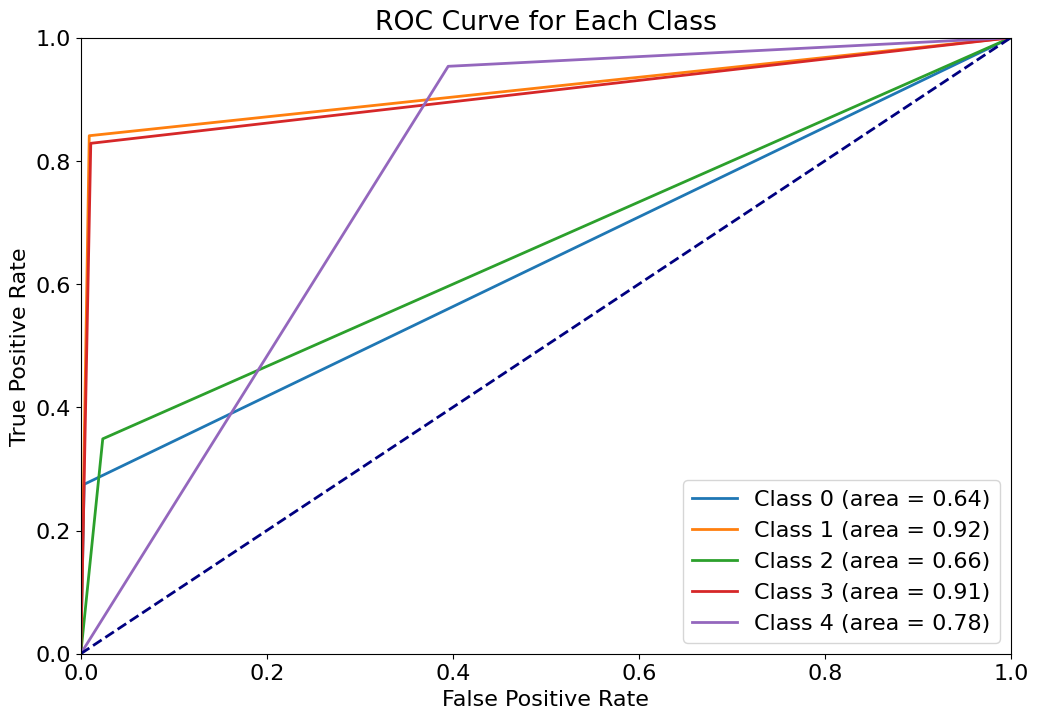

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(labels_test_categorical[:, i], labels_test_pred == i)
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plotting the ROC Curve for each class
plt.figure(figsize=(12, 8))
lw = 2
for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], lw=lw, label='Class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Each Class')
plt.legend(loc='lower right')
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score

# Calculate the AUROC score for the test predictions
auroc_score = roc_auc_score(labels_test_categorical, image_resnet_model.predict(images_test))
print(f'AUROC score: {auroc_score:01.3f}') # auroc_score

19/19 [==============================] - 8s 444ms/step
AUROC score: 0.906


In [ ]:
from sklearn import metrics

# Compute the F1 score for the multiclass classification problem
# Using labels_test_pred instead of test_pred for correct prediction array
f1_score = metrics.f1_score(labels_test_int, labels_test_pred, average='macro')
print(f'F1 score: {f1_score:01.3f}')

F1 score: 0.687


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=1ea886fc-17cd-4477-8de0-3ecc0d678ec3' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>